# Frobenius Motif Pipeline

Unified pipeline for motif segmentation, clustering, labeling, and interpretation.

**Cells are independent** — re-run any cell after the setup cell without affecting others.

| Cell | Stage | What it does |
|------|-------|-------------|
| 1 | Setup | Load panels, approved bboxes, labels into shared state |
| 2 | Segment | Review detections, manual draw, SAM Refine — all in one UI |
| 3 | Cluster | CLIP embeddings + HDBSCAN clustering |
| 4 | Gallery | Browse motifs grouped by cluster / panel / label |
| 5 | Label | Edit labels + LLM Suggest via Claude |
| 6 | Interpret | LLM-powered motif and panel interpretation |
| 7 | Export | Save state, export crops, progress charts |

**Data provenance**: every bbox, label, and cluster assignment records its source
(`manual`, `sam_prompted`, `llm`, `human`) and timestamp.

In [51]:
import json
import io
import re
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from PIL import Image

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
_NB   = Path(".").resolve()                           # src/python/
_REPO = _NB.parent.parent
_ANA  = _REPO / "frobenius_artifacts/analysis"

PANELS_DIR    = _ANA / "panels"
ANNOTATED_DIR = _ANA / "annotated"
MOTIFS_DIR    = _ANA / "motifs"
LABELS_PATH   = _ANA / "motif_labels.json"

# ── Shared state ──────────────────────────────────────────────────────────────
from panel_art.pipeline_state import PipelineState

PS = PipelineState()
PS.load_from_disk(
    annotated_dir=ANNOTATED_DIR,
    panels_dir=PANELS_DIR,
    labels_path=LABELS_PATH,
)

# Quick summary
_n_manual = len(PS.manual_templates())
_n_labeled = sum(1 for m in PS.motifs if m.label)
print(f"Manual templates: {_n_manual}  |  Labeled: {_n_labeled}")
print("Re-run this cell to reload from disk (revert all in-memory changes)")

  Labels merged: 1/156
PipelineState: 43 panels, 156 motifs, 43 with approved files
Manual templates: 63  |  Labeled: 1
Re-run this cell to reload from disk (revert all in-memory changes)


HTML(value="<h3 style='margin:4px 0'>Stage 1: Segment</h3>")

Dropdown(description='Panel:', layout=Layout(width='90%'), options=(('EBA-Div_00302_q166558_i1_panel_00', 'EBA…

HTML(value="<div style='font-size:11px;color:#999;margin:2px 0 4px 0'><b>sub-crop filter</b>: higher = stricte…

Output()

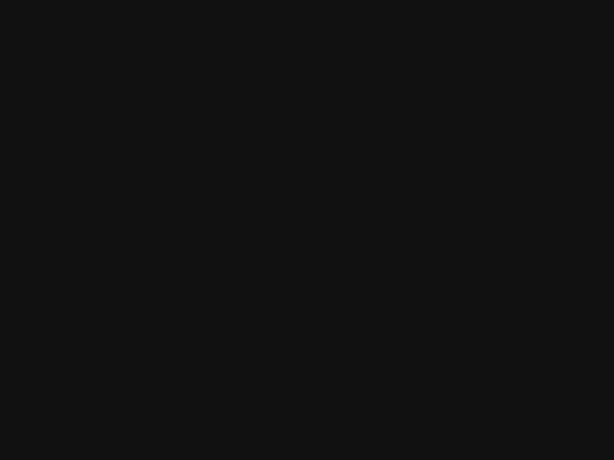

HTML(value="<b style='font-size:13px'>Detection cards</b>")

Output()

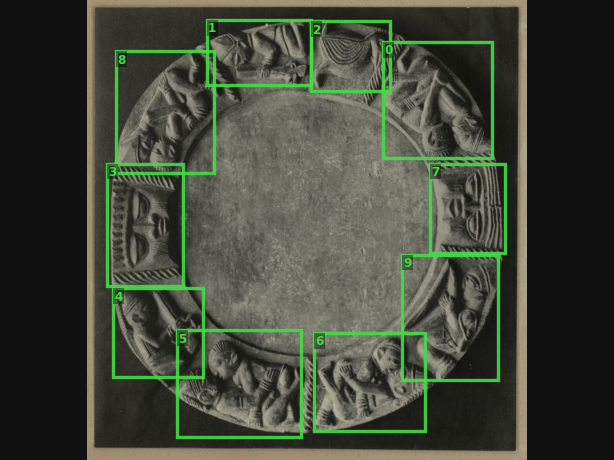

In [52]:
%matplotlib widget
## ── Segment: Panel Review + Manual Draw ─────────────────────────────────────

import io as _io

# ── Helpers ───────────────────────────────────────────────────────────────────
def _containment(a, b):
    ax1, ay1 = a["x"], a["y"];  ax2, ay2 = ax1 + a["w"], ay1 + a["h"]
    bx1, by1 = b["x"], b["y"];  bx2, by2 = bx1 + b["w"], by1 + b["h"]
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    if ix2 <= ix1 or iy2 <= iy1: return 0.0
    inter = (ix2 - ix1) * (iy2 - iy1)
    min_area = min(a["w"] * a["h"], b["w"] * b["h"])
    return inter / min_area if min_area > 0 else 0.0

def _auto_exclude(dets, threshold):
    n = len(dets)
    areas = [d.bbox["w"] * d.bbox["h"] for d in dets]
    by_size = sorted(range(n), key=lambda i: -areas[i])
    suppress = set()
    for pos, i in enumerate(by_size):
        if i in suppress: continue
        for j in by_size[pos + 1:]:
            if j not in suppress and _containment(dets[i].bbox, dets[j].bbox) >= threshold:
                suppress.add(j)
    return suppress

def _thumb(panel_img, bbox, size=96, bg=(30, 30, 30)):
    iw, ih = panel_img.size
    b = bbox
    crop = panel_img.crop((max(0, b["x"]), max(0, b["y"]),
                           min(iw, b["x"] + b["w"]), min(ih, b["y"] + b["h"])))
    crop.thumbnail((size, size))
    sq = Image.new("RGB", (size, size), bg)
    sq.paste(crop, ((size - crop.width) // 2, (size - crop.height) // 2))
    buf = _io.BytesIO();  sq.save(buf, format="PNG")
    return widgets.Image(value=buf.getvalue(), format="png", width=size, height=size)


# ── Persistent figure ─────────────────────────────────────────────────────────
MAX_DISPLAY_W = 900
_seg_fig, _seg_ax = plt.subplots(1, 1, dpi=96,
    gridspec_kw={"left": 0, "right": 1, "top": 1, "bottom": 0})
_seg_fig.patch.set_facecolor("#111")
_seg_ax.set_facecolor("#111")
_seg_ax.axis("off")

_seg_state = {"stem": None, "dirty": False}
_seg_img_cache = {"stem": None, "arr": None, "scale": 1.0}
_seg_drag = {"active": False, "x0": 0, "y0": 0}
_seg_draw = {"mode_on": False}
_seg_no_obs = [False]


def _seg_scale():
    if _seg_state["stem"] is None: return 1.0
    info = PS.panels[_seg_state["stem"]]
    return min(1.0, MAX_DISPLAY_W / info.width)


def _seg_motifs():
    # Current panel motifs from PipelineState.
    stem = _seg_state["stem"]
    return PS.motifs_for_panel(stem) if stem else []


def _seg_redraw(with_pending=False):
    if _seg_state["stem"] is None: return
    stem = _seg_state["stem"]
    panel_img = PS.panel_image(stem)
    iw, ih = panel_img.size
    scale = min(1.0, MAX_DISPLAY_W / iw)
    dw, dh = int(iw * scale), int(ih * scale)

    _seg_ax.clear()
    _seg_ax.axis("off")

    if _seg_img_cache["stem"] != stem:
        _seg_img_cache["arr"] = np.array(panel_img.resize((dw, dh), Image.LANCZOS))
        _seg_img_cache["stem"] = stem
        _seg_img_cache["scale"] = scale
    _seg_ax.imshow(_seg_img_cache["arr"])

    motifs = _seg_motifs()
    for i, m in enumerate(motifs):
        b = m.bbox
        x, y, w, h = b["x"]*scale, b["y"]*scale, b["w"]*scale, b["h"]*scale
        inc = _seg_cbs[i].value if i < len(_seg_cbs) else m.included
        color = "#44dd44" if inc else "#ff4444"
        _seg_ax.add_patch(mpatches.Rectangle(
            (x, y), w, h,
            linewidth=2.5 if inc else 1.5,
            edgecolor=color, facecolor="none", alpha=0.9 if inc else 0.55))
        _seg_ax.text(x+3, y+3, str(m.index),
            fontsize=max(6, int(10*scale)), color=color, va="top", fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.4, pad=1, linewidth=0))

    if with_pending:
        pb = {"x": w_mx.value, "y": w_my.value, "w": w_mw.value, "h": w_mh.value}
        if pb["w"] > 0 and pb["h"] > 0:
            x, y = pb["x"]*scale, pb["y"]*scale
            w2, h2 = pb["w"]*scale, pb["h"]*scale
            _seg_ax.add_patch(mpatches.Rectangle(
                (x, y), w2, h2, linewidth=0, facecolor="#00ffff", alpha=0.12))
            _seg_ax.add_patch(mpatches.Rectangle(
                (x, y), w2, h2, linewidth=2.5, edgecolor="#00ffff",
                facecolor="none", alpha=0.95, linestyle=(0, (6, 3))))
            _seg_ax.text(x+4, y+4, "new",
                fontsize=max(7, int(11*scale)), color="#00ffff", va="top",
                fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.45, pad=1, linewidth=0))

    if _seg_draw["mode_on"]:
        _seg_ax.set_title("Draw mode ON — drag to select a motif region",
                          color="#00cccc", fontsize=10, pad=3)
    _seg_fig.canvas.draw_idle()


# ── Mouse handlers ────────────────────────────────────────────────────────────
def _seg_on_press(event):
    if not _seg_draw["mode_on"]: return
    if event.inaxes != _seg_ax or event.button != 1: return
    scale = _seg_img_cache["scale"] or _seg_scale()
    _seg_drag["active"] = True
    _seg_drag["x0"] = max(0, int(event.xdata / scale)) if event.xdata is not None else 0
    _seg_drag["y0"] = max(0, int(event.ydata / scale)) if event.ydata is not None else 0

def _seg_on_move(event):
    if not _seg_drag["active"] or not _seg_draw["mode_on"]: return
    if event.inaxes != _seg_ax or event.xdata is None: return
    scale = _seg_img_cache["scale"] or _seg_scale()
    x0, y0 = _seg_drag["x0"], _seg_drag["y0"]
    x1 = max(0, int(event.xdata / scale))
    y1 = max(0, int(event.ydata / scale))
    if _seg_state["stem"]:
        info = PS.panels[_seg_state["stem"]]
        x1 = min(x1, info.width - 1); y1 = min(y1, info.height - 1)
    x = min(x0, x1); y = min(y0, y1)
    w = max(1, abs(x1 - x0)); h = max(1, abs(y1 - y0))
    _seg_no_obs[0] = True
    w_mx.value = x; w_my.value = y; w_mw.value = w; w_mh.value = h
    _seg_no_obs[0] = False
    _seg_redraw(with_pending=True)

def _seg_on_release(event):
    if not _seg_drag["active"]: return
    _seg_drag["active"] = False
    _seg_redraw(with_pending=True)

_seg_fig.canvas.mpl_connect("button_press_event", _seg_on_press)
_seg_fig.canvas.mpl_connect("motion_notify_event", _seg_on_move)
_seg_fig.canvas.mpl_connect("button_release_event", _seg_on_release)


# ── Widgets ───────────────────────────────────────────────────────────────────
_panel_opts = [(s, s) for s in sorted(PS.panels.keys())]
w_seg_panel = widgets.Dropdown(options=_panel_opts, description="Panel:",
    style={"description_width": "60px"}, layout=widgets.Layout(width="90%"))

_sl_kw = dict(continuous_update=False, style={"description_width": "140px"},
              layout=widgets.Layout(width="55%"))
w_subcrop = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.75,
    description="sub-crop filter", readout_format=".2f", **_sl_kw)
w_min_qual = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.0,
    description="min SAM quality", readout_format=".2f", **_sl_kw)

btn_save    = widgets.Button(description="Save approved", button_style="success",
                             layout=widgets.Layout(width="150px"))
btn_revert  = widgets.Button(description="Revert to saved", button_style="danger",
                             layout=widgets.Layout(width="135px"))
btn_draw    = widgets.Button(description="[D] Draw bbox", button_style="",
                             layout=widgets.Layout(width="130px"))

_draw_sl = dict(continuous_update=True, style={"description_width": "18px"},
                layout=widgets.Layout(width="88%"))
w_mx = widgets.IntSlider(value=0, min=0, max=2000, step=1, description="x", **_draw_sl)
w_my = widgets.IntSlider(value=0, min=0, max=2000, step=1, description="y", **_draw_sl)
w_mw = widgets.IntSlider(value=100, min=1, max=2000, step=1, description="w", **_draw_sl)
w_mh = widgets.IntSlider(value=100, min=1, max=2000, step=1, description="h", **_draw_sl)
btn_add = widgets.Button(description="Add bbox ✓", button_style="info",
                         layout=widgets.Layout(width="110px"))

out_seg_cards  = widgets.Output()
out_seg_status = widgets.Output()

_seg_cbs: list[widgets.Checkbox] = []  # detection card checkboxes


# ── Handlers ──────────────────────────────────────────────────────────────────
def _seg_mark_dirty():
    _seg_state["dirty"] = True
    btn_save.description = "Save approved ●"
    btn_save.button_style = "warning"

def _seg_mark_clean():
    _seg_state["dirty"] = False
    btn_save.description = "Save approved"
    btn_save.button_style = "success"

def _seg_build_cards():
    global _seg_cbs
    stem = _seg_state["stem"]
    if not stem: return
    motifs = _seg_motifs()
    panel_img = PS.panel_image(stem)
    auto_excl = _auto_exclude(motifs, w_subcrop.value)
    min_q = w_min_qual.value

    cbs, cards = [], []
    for i, m in enumerate(motifs):
        tw = _thumb(panel_img, m.bbox)
        below_q = m.predicted_iou < min_q
        auto_tag = " ⚠ sub-crop" if i in auto_excl else (" ⚠ low quality" if below_q else "")
        src_tag = f" [{m.source}]"
        cb = widgets.Checkbox(value=(i not in auto_excl and not below_q and m.included),
                              description="Include", indent=False,
                              style={"description_width": "initial"},
                              layout=widgets.Layout(width="100px"))
        cbs.append(cb)
        cb.observe(lambda c: (_seg_mark_dirty(), _seg_redraw()), names="value")
        iou_s = f"{m.predicted_iou:.3f}"
        area_s = f"{m.area_ratio:.3f}"
        b = m.bbox
        meta = widgets.HTML(
            f"<div style='font-size:11px;line-height:1.5;color:#ccc'>"
            f"<b>#{m.index}</b> {m.scale}{src_tag}<br>"
            f"area: {area_s}<br>iou: {iou_s}<br>"
            f"{b['w']}×{b['h']} px"
            f"<span style='color:#ff8888'>{auto_tag}</span></div>")
        cards.append(widgets.VBox([tw, meta, cb],
            layout=widgets.Layout(border="1px solid #333", padding="4px",
                                  margin="3px", width="120px", background="#1a1a1a")))

    _seg_cbs = cbs
    rows = [widgets.HBox(cards[r:r+6]) for r in range(0, len(cards), 6)]
    out_seg_cards.clear_output(wait=True)
    with out_seg_cards:
        display(widgets.VBox(rows) if rows else widgets.HTML("<i>No detections</i>"))


def _seg_load_panel(_=None):
    stem = w_seg_panel.value
    old_stem = _seg_state["stem"]
    if _seg_state["dirty"] and old_stem and old_stem != stem:
        _seg_save()  # autosave on panel switch
    _seg_state["stem"] = stem
    _seg_img_cache["stem"] = None  # invalidate
    info = PS.panels[stem]
    w_mx.value = 0; w_my.value = 0
    w_mw.value = min(100, info.width); w_mh.value = min(100, info.height)
    w_mx.max = info.width - 1; w_my.max = info.height - 1
    w_mw.max = info.width; w_mh.max = info.height
    _seg_mark_clean()
    _seg_build_cards()
    _seg_redraw()
    out_seg_status.clear_output()
    with out_seg_status:
        motifs = _seg_motifs()
        n_inc = sum(1 for m in motifs if m.included)
        print(f"{stem} — {len(motifs)} detections ({n_inc} included)")
        print(f"Panel: {info.width}×{info.height} px")


def _seg_save(_=None):
    stem = _seg_state["stem"]
    if not stem: return
    # Sync checkbox state → MotifRecord.included
    motifs = _seg_motifs()
    for i, m in enumerate(motifs):
        m.included = _seg_cbs[i].value if i < len(_seg_cbs) else m.included
    path = PS.save_approved(stem)
    _seg_mark_clean()
    n = sum(1 for m in motifs if m.included)
    out_seg_status.clear_output()
    with out_seg_status:
        print(f"Saved: {n}/{len(motifs)} → {path.name}")


def _seg_revert(_=None):
    _seg_state["dirty"] = False
    # Reload this panel from disk
    stem = _seg_state["stem"]
    if not stem: return
    PS.motifs = [m for m in PS.motifs if m.panel_stem != stem]
    # Re-read from disk
    approved_path = ANNOTATED_DIR / f"{stem}_approved.json"
    det_path = ANNOTATED_DIR / f"{stem}_detections.json"
    src_path = approved_path if approved_path.exists() else det_path
    if src_path.exists():
        raw = json.loads(src_path.read_text())
        for d in raw:
            from panel_art.pipeline_state import MotifRecord
            PS.motifs.append(MotifRecord(
                panel_stem=stem, index=d.get("index", 0), bbox=d["bbox"],
                scale=d.get("scale", "motif"),
                area_ratio=d.get("area_ratio", 0.0),
                predicted_iou=d.get("predicted_iou", d.get("pred_iou", 0.0)),
                stability_score=d.get("stability_score", 0.0),
                source=d.get("source", "sam_auto"),
                created_at=d.get("created_at", ""), included=True))
    _seg_load_panel()
    out_seg_status.clear_output()
    with out_seg_status:
        print(f"Reverted to saved state — {len(_seg_motifs())} detections")


def _seg_on_draw_toggle(_=None):
    _seg_draw["mode_on"] = not _seg_draw["mode_on"]
    if _seg_draw["mode_on"]:
        btn_draw.description = "[D] Draw ● ON"
        btn_draw.button_style = "info"
    else:
        btn_draw.description = "[D] Draw bbox"
        btn_draw.button_style = ""
        _seg_drag["active"] = False
    _seg_redraw(with_pending=_seg_draw["mode_on"])


def _seg_on_add(_=None):
    # Add pending bbox — works for both manual draws and SAM candidates
    stem = _seg_state["stem"]
    if not stem: return
    bbox = {"x": w_mx.value, "y": w_my.value, "w": w_mw.value, "h": w_mh.value}
    if bbox["w"] <= 0 or bbox["h"] <= 0: return
    cand = PS.next_draft(stem)
    if cand is not None:
        rec = PS.accept_draft(stem, adjusted_bbox=bbox)
        tag = "sam_prompted"
        _seg_load_next_candidate()
        _seg_show_sam_status()
    else:
        rec = PS.add_motif(stem, bbox, source="manual")
        tag = "manual"
    _seg_mark_dirty()
    _seg_build_cards()
    has_next = PS.next_draft(stem) is not None
    _seg_redraw(with_pending=has_next)
    out_seg_status.clear_output()
    with out_seg_status:
        print(f"Added {tag} bbox #{rec.index}: ({bbox['x']},{bbox['y']}) {bbox['w']}×{bbox['h']}")


def _seg_on_slider(_=None):
    if _seg_no_obs[0]: return
    _seg_redraw(with_pending=True)

def _seg_on_filter(_=None):
    _seg_build_cards()
    _seg_redraw()


# ── SAM Refine (integrated) ──────────────────────────────────────────────────
import panel_art.motif_segment as _ms
import importlib; importlib.reload(_ms)

_ref_sl = dict(continuous_update=False, style={"description_width": "130px"},
               layout=widgets.Layout(width="48%"))
w_sam_score = widgets.FloatSlider(min=0.50, max=0.99, step=0.01, value=0.85,
    description="min SAM score", readout_format=".2f", **_ref_sl)
w_sam_min_area = widgets.FloatSlider(min=0.005, max=0.20, step=0.005, value=0.01,
    description="min area %", readout_format=".1%", **_ref_sl)
w_sam_max_area = widgets.FloatSlider(min=0.10, max=0.80, step=0.05, value=0.50,
    description="max area %", readout_format=".0%", **_ref_sl)
w_sam_edge = widgets.FloatSlider(min=0.0, max=0.15, step=0.005, value=0.03,
    description="min edge density", readout_format=".1%", **_ref_sl)

btn_sam_gen  = widgets.Button(description="SAM Generate", button_style="",
    layout=widgets.Layout(width="140px"))
btn_sam_skip = widgets.Button(description="Skip →", button_style="warning",
    layout=widgets.Layout(width="90px"), disabled=True)
btn_sam_reset = widgets.Button(description="Reset Queue", button_style="",
    layout=widgets.Layout(width="110px"))
out_sam_status = widgets.Output()


def _seg_load_next_candidate():
    stem = _seg_state["stem"]
    if not stem: return
    cand = PS.next_draft(stem)
    if cand is None:
        btn_sam_skip.disabled = True
        return
    btn_sam_skip.disabled = False
    rec = cand["record"]
    b = rec.bbox
    info = PS.panels[stem]
    _seg_no_obs[0] = True
    w_mx.max = info.width - 1; w_my.max = info.height - 1
    w_mw.max = info.width; w_mh.max = info.height
    w_mx.value = b["x"]; w_my.value = b["y"]
    w_mw.value = b["w"]; w_mh.value = b["h"]
    _seg_no_obs[0] = False
    _seg_redraw(with_pending=True)


def _seg_show_sam_status():
    stem = _seg_state["stem"]
    if not stem: return
    total, cursor, accepted, skipped = PS.draft_count(stem)
    cand = PS.next_draft(stem)
    out_sam_status.clear_output()
    with out_sam_status:
        if cand is None:
            if total > 0:
                print(f"Queue done. Accepted: {accepted}, Skipped: {skipped}/{total}")
            btn_sam_skip.disabled = True
        else:
            rec = cand["record"]
            print(f"SAM {cursor+1}/{total} — score={rec.predicted_iou:.3f}, "
                  f"edge={cand['edge_density']:.2f}, novelty={cand['novelty']:.2f}")
            print(f"Accepted: {accepted} | Skipped: {skipped} | Remaining: {total - cursor}")
            print("Adjust with drag/sliders, then Add bbox or Skip")
            btn_sam_skip.disabled = False


def _seg_on_sam_gen(_=None):
    stem = _seg_state["stem"]
    if not stem: return
    btn_sam_gen.description = "Running SAM..."
    btn_sam_gen.disabled = True
    out_sam_status.clear_output()
    with out_sam_status: print("Loading SAM...")
    try:
        existing = [m.bbox for m in PS.motifs_for_panel(stem) if m.included]
        templates = PS.manual_templates()
        img_np = np.array(PS.panel_image(stem))
        candidates = _ms.prompted_segment(
            img_np, existing,
            approved_templates=templates or None,
            min_score=w_sam_score.value,
            min_area=w_sam_min_area.value,
            max_area=w_sam_max_area.value,
            min_edge_density=w_sam_edge.value,
            verbose=True,
        )
        n = PS.cache_sam_candidates(stem, candidates)
        out_sam_status.clear_output()
        with out_sam_status: print(f"Generated {n} candidates")
        _seg_load_next_candidate()
        _seg_show_sam_status()
    except Exception:
        out_sam_status.clear_output()
        with out_sam_status: import traceback; traceback.print_exc()
    finally:
        btn_sam_gen.description = "SAM Generate"
        btn_sam_gen.disabled = False


def _seg_on_sam_skip(_=None):
    stem = _seg_state["stem"]
    if not stem: return
    PS.skip_draft(stem)
    _seg_load_next_candidate()
    _seg_show_sam_status()


def _seg_on_sam_reset(_=None):
    stem = _seg_state["stem"]
    if not stem: return
    PS.reset_draft_queue(stem)
    _seg_load_next_candidate()
    _seg_show_sam_status()


# ── Wire up ───────────────────────────────────────────────────────────────────
w_seg_panel.observe(_seg_load_panel, names="value")
w_subcrop.observe(_seg_on_filter, names="value")
w_min_qual.observe(_seg_on_filter, names="value")
btn_save.on_click(_seg_save)
btn_revert.on_click(_seg_revert)
btn_draw.on_click(_seg_on_draw_toggle)
btn_add.on_click(_seg_on_add)
btn_sam_gen.on_click(_seg_on_sam_gen)
btn_sam_skip.on_click(_seg_on_sam_skip)
btn_sam_reset.on_click(_seg_on_sam_reset)
for _w in (w_mx, w_my, w_mw, w_mh):
    _w.observe(_seg_on_slider, names="value")


# ── Layout ────────────────────────────────────────────────────────────────────
_filter_help = widgets.HTML(
    "<div style='font-size:11px;color:#999;margin:2px 0 4px 0'>"
    "<b>sub-crop filter</b>: higher = stricter, auto-excludes nested bboxes "
    "&nbsp;|&nbsp; "
    "<b>min SAM quality</b>: raise to hide low-confidence detections</div>")

_draw_section = widgets.VBox([
    widgets.HTML("<b style='font-size:12px;color:#00cccc'>"
                 "Pending bbox — drag on image, use sliders, or SAM Generate:</b>"),
    widgets.HBox([
        widgets.VBox([widgets.HBox([w_mx]), widgets.HBox([w_my])],
                     layout=widgets.Layout(width="50%")),
        widgets.VBox([widgets.HBox([w_mw]), widgets.HBox([w_mh])],
                     layout=widgets.Layout(width="50%")),
    ]),
    widgets.HBox([btn_add, btn_sam_skip]),
], layout=widgets.Layout(border="1px solid #006666", padding="6px 10px",
                         margin="4px 0", background="#001a1a"))

_sam_section = widgets.VBox([
    widgets.HTML("<b style='font-size:12px;color:#dd8800'>"
                 "SAM Refine — candidates appear one at a time as pending bboxes:</b>"),
    widgets.HBox([w_sam_score, w_sam_min_area]),
    widgets.HBox([w_sam_max_area, w_sam_edge]),
    widgets.HBox([btn_sam_gen, btn_sam_reset]),
    out_sam_status,
], layout=widgets.Layout(border="1px solid #664400", padding="6px 10px",
                         margin="4px 0", background="#1a0d00"))

display(
    widgets.HTML("<h3 style='margin:4px 0'>Stage 1: Segment</h3>"),
    w_seg_panel, _filter_help,
    widgets.HBox([w_subcrop, w_min_qual]),
    widgets.HBox([btn_draw, btn_save, btn_revert]),
    out_seg_status,
    _seg_fig.canvas,
    _draw_section,
    _sam_section,
    widgets.HTML("<b style='font-size:13px'>Detection cards</b>"),
    out_seg_cards,
)
_seg_load_panel()

In [53]:
## ── Stage 2: Cluster — CLIP Embeddings + HDBSCAN ────────────────────────────
#
# Computes CLIP embeddings from in-memory crops (no disk files needed),
# runs t-SNE for 2D layout, HDBSCAN for clustering.
# Cluster assignments are stored back on PS.motifs[].cluster.

import cv2 as _cv2
import torch as _torch
import open_clip as _oc
from sklearn.manifold import TSNE as _TSNE
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim
from sklearn.cluster import AgglomerativeClustering as _Agglom
import hdbscan as _hdbscan

# ── Preprocessing mode ────────────────────────────────────────────────────────
CLIP_MODEL  = "ViT-B-32"
CLIP_WEIGHTS = "openai"
BATCH = 32

def _preprocess_crop(img, mode):
    # Apply mode transform before CLIP
    img = img.convert("RGB")
    arr = np.array(img)
    if mode == "color":
        return img
    elif mode == "grayscale":
        gray = _cv2.cvtColor(arr, _cv2.COLOR_RGB2GRAY)
        return Image.fromarray(np.stack([gray]*3, axis=-1))
    elif mode == "edges":
        gray = _cv2.cvtColor(arr, _cv2.COLOR_RGB2GRAY)
        med = float(np.median(gray))
        edges = _cv2.Canny(gray, max(0, 0.5*med), min(255, 1.5*med))
        edges = 255 - edges
        return Image.fromarray(np.stack([edges]*3, axis=-1))
    elif mode == "clahe":
        lab = _cv2.cvtColor(arr, _cv2.COLOR_RGB2LAB).astype(np.uint8)
        cl = _cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        lab[:,:,0] = cl.apply(lab[:,:,0])
        return Image.fromarray(_cv2.cvtColor(lab, _cv2.COLOR_LAB2RGB))
    return img

_clip_cache = {}
def _get_clip():
    if not _clip_cache:
        device = "cuda" if _torch.cuda.is_available() else "cpu"
        print(f"Loading CLIP {CLIP_MODEL} on {device}...")
        model, _, prep = _oc.create_model_and_transforms(CLIP_MODEL, pretrained=CLIP_WEIGHTS)
        model = model.to(device).eval()
        _clip_cache.update(model=model, prep=prep, device=device)
    return _clip_cache["model"], _clip_cache["prep"], _clip_cache["device"]


# ── Widgets ───────────────────────────────────────────────────────────────────
_cl_sl = dict(continuous_update=False, style={"description_width": "160px"},
              layout=widgets.Layout(width="55%"))

w_prep_mode = widgets.ToggleButtons(
    options=["edges", "grayscale", "color", "clahe"], value="edges",
    description="Preprocessing:", style={"description_width": "120px", "button_width": "80px"})

btn_embed = widgets.Button(description="Compute Embeddings", button_style="info",
    layout=widgets.Layout(width="200px"))

w_mcs    = widgets.IntSlider(min=2, max=20, step=1, value=3,
    description="min_cluster_size", **_cl_sl)
w_ms     = widgets.IntSlider(min=1, max=10, step=1, value=1,
    description="min_samples", **_cl_sl)
w_method = widgets.ToggleButtons(options=["leaf", "eom"], value="leaf",
    description="selection method",
    style={"description_width": "160px", "button_width": "70px"})
w_pass2  = widgets.Checkbox(value=True,
    description="Sub-cluster noise points (pass 2)",
    style={"description_width": "initial"})
w_nsub   = widgets.IntSlider(min=2, max=30, step=1, value=8,
    description="pass-2 sub-clusters", **_cl_sl)

out_embed  = widgets.Output()
out_clust  = widgets.Output()

# ── State ─────────────────────────────────────────────────────────────────────
_cl_state = {
    "motif_keys": [],     # ordered keys matching embeddings rows
    "embeddings": None,
    "coords": None,       # t-SNE 2D
    "sim_matrix": None,
    "labels": None,
    "n_clusters": 0,
}


def _compute_embeddings(_=None):
    mode = w_prep_mode.value
    included = PS.included_motifs()
    if not included:
        with out_embed: print("No included motifs — approve some in Stage 1 first")
        return

    btn_embed.description = "Computing..."
    btn_embed.disabled = True
    out_embed.clear_output()

    try:
        model, prep, device = _get_clip()
        keys, all_feats = [], []
        with out_embed:
            print(f"Embedding {len(included)} motifs (mode={mode})...")

        for i in range(0, len(included), BATCH):
            batch = included[i:i+BATCH]
            imgs = _torch.stack([
                prep(_preprocess_crop(PS.crop(m), mode)) for m in batch
            ]).to(device)
            with _torch.no_grad():
                feats = model.encode_image(imgs)
                feats = feats / feats.norm(dim=-1, keepdim=True)
            all_feats.append(feats.cpu().float().numpy())
            keys.extend(m.motif_key for m in batch)

        embs = np.vstack(all_feats)
        N = len(keys)

        # t-SNE
        with out_embed:
            print(f"Running t-SNE (n={N})...")
        perp = min(30, max(5, N // 8))
        import sklearn as _sk
        _ver = tuple(int(x) for x in _sk.__version__.split(".")[:2])
        _ik = "max_iter" if _ver >= (1, 5) else "n_iter"
        coords = _TSNE(n_components=2, perplexity=perp, metric="euclidean",
                        random_state=42, init="pca", **{_ik: 1500}).fit_transform(embs)

        sim = _cos_sim(embs)

        _cl_state["motif_keys"] = keys
        _cl_state["embeddings"] = embs
        _cl_state["coords"] = coords
        _cl_state["sim_matrix"] = sim
        PS.embeddings = embs
        PS.tsne_xy = coords
        PS.sim_matrix = sim

        out_embed.clear_output()
        with out_embed:
            print(f"Done: {embs.shape} embeddings, t-SNE coords ready")

        # Run initial clustering
        _run_clustering()
    except Exception:
        out_embed.clear_output()
        with out_embed:
            import traceback; traceback.print_exc()
    finally:
        btn_embed.description = "Compute Embeddings"
        btn_embed.disabled = False


def _run_clustering(_=None):
    embs = _cl_state["embeddings"]
    if embs is None:
        with out_clust: print("Compute embeddings first")
        return

    mcs, ms = w_mcs.value, w_ms.value
    method = w_method.value
    do_pass2, n_sub = w_pass2.value, w_nsub.value

    cl = _hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms,
                           metric="euclidean", cluster_selection_method=method)
    lbl = cl.fit_predict(embs).copy()
    nc1 = len(set(lbl)) - (1 if -1 in lbl else 0)
    nn = int((lbl == -1).sum())

    nc2 = 0
    if do_pass2 and nn > 0:
        noise_idx = np.where(lbl == -1)[0]
        n_sub_real = min(n_sub, len(noise_idx))
        if n_sub_real >= 2:
            sub_lbl = _Agglom(n_clusters=n_sub_real).fit_predict(embs[noise_idx])
            for i, ni in enumerate(noise_idx):
                lbl[ni] = nc1 + sub_lbl[i]
            nc2 = n_sub_real

    _cl_state["labels"] = lbl
    _cl_state["n_clusters"] = nc1 + nc2

    # Write back to PS.motifs
    keys = _cl_state["motif_keys"]
    key_to_lbl = dict(zip(keys, lbl))
    for m in PS.motifs:
        if m.motif_key in key_to_lbl:
            m.cluster = int(key_to_lbl[m.motif_key])

    remaining = int((lbl == -1).sum())
    out_clust.clear_output()
    with out_clust:
        print(f"Pass 1: {nc1} clusters, {nn} noise  [mcs={mcs}, ms={ms}, {method}]")
        if do_pass2 and nc2:
            print(f"Pass 2: {nc2} sub-clusters from {nn} noise points")
        print(f"Total: {nc1+nc2} clusters, {remaining} unclustered")
        for c in sorted(set(lbl)):
            tag = "noise" if c == -1 else f"C{c:2d}"
            n = int((lbl == c).sum())
            bar = "█" * min(40, n)
            print(f"  {tag}: {n:3d}  {bar}")





# ── Wire up ───────────────────────────────────────────────────────────────────
btn_embed.on_click(_compute_embeddings)
for _w in (w_mcs, w_ms, w_method, w_pass2, w_nsub):
    _w.observe(_run_clustering, names="value")


# ── Layout ────────────────────────────────────────────────────────────────────
display(
    widgets.HTML("<h3 style='margin:4px 0'>Stage 2: Cluster</h3>"),
    widgets.HTML("<div style='font-size:12px;color:#999;margin-bottom:4px'>"
        "Select preprocessing mode, compute embeddings, then tune clustering. "
        "Cluster assignments are saved on each motif record. "
        "View scatter map in Stage 3 (Gallery).</div>"),
    w_prep_mode, btn_embed, out_embed,
    widgets.HTML("<b style='font-size:13px;margin-top:8px'>HDBSCAN clustering</b>"),
    w_mcs, w_ms, w_method,
    widgets.HTML("<b>Pass 2 — sub-cluster noise</b>"),
    w_pass2, w_nsub,
    out_clust,
)

HTML(value="<h3 style='margin:4px 0'>Stage 2: Cluster</h3>")

HTML(value="<div style='font-size:12px;color:#999;margin-bottom:4px'>Select preprocessing mode, compute embedd…

ToggleButtons(description='Preprocessing:', options=('edges', 'grayscale', 'color', 'clahe'), style=ToggleButt…

Button(button_style='info', description='Compute Embeddings', layout=Layout(width='200px'), style=ButtonStyle(…

Output()

...

ToggleButtons(description='selection method', options=('leaf', 'eom'), style=ToggleButtonsStyle(button_width='…

HTML(value='<b>Pass 2 — sub-cluster noise</b>')

Checkbox(value=True, description='Sub-cluster noise points (pass 2)', style=CheckboxStyle(description_width='i…

IntSlider(value=8, continuous_update=False, description='pass-2 sub-clusters', layout=Layout(width='55%'), max…

Output()

HTML(value="<h3 style='margin:4px 0'>Stage 3: Gallery</h3>")

Output()

Output()

HTML(value="<b style='font-size:13px;margin-top:8px'>Cluster scatter map</b><div style='font-size:11px;color:#…

Output()

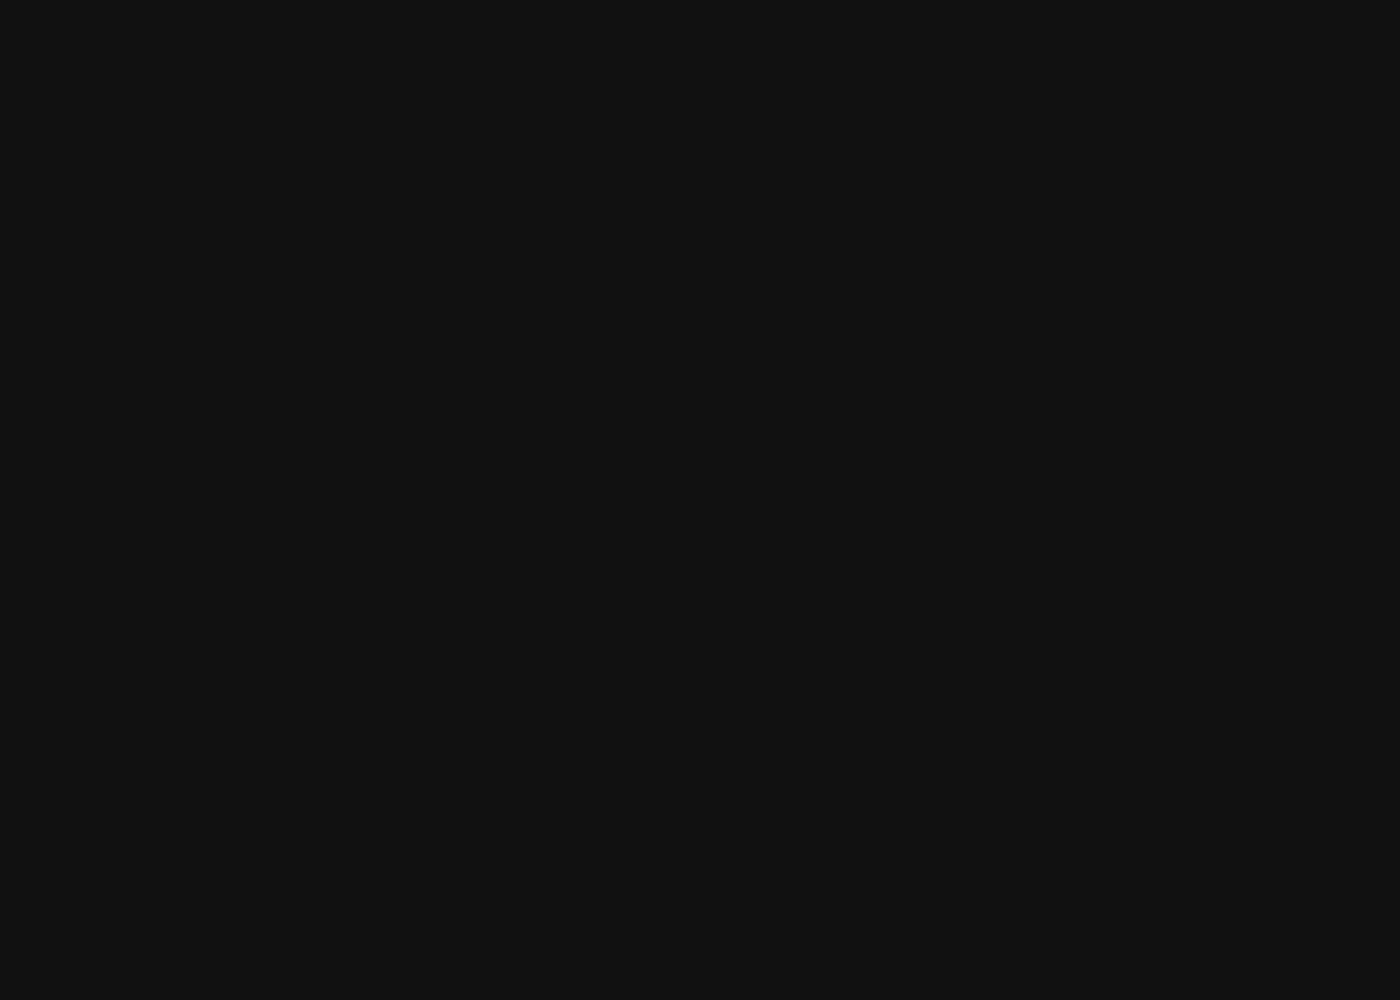

HTML(value="<b style='font-size:13px;margin-top:8px'>Context</b>")

Output()

Output()

In [54]:
## ── Stage 3: Gallery ────────────────────────────────────────────────────────
#
# Browse motifs grouped by cluster, panel, or label.
# Click a thumbnail to select it as active for the Label stage.

import io as _gio

THUMB_PX = 72

_gal_state = {"cursor": 0, "selected": set()}
_gal_cards: dict = {}
_gal_dots: dict = {}
_gal_chks: dict = {}
# Callbacks that fire when gallery selection changes — label cell registers into this
_gal_on_select_cbs: list = []

out_gallery = widgets.Output()
out_context = widgets.Output()
out_nn_strip = widgets.Output()
out_gal_scatter = widgets.Output()

w_group_by = widgets.ToggleButtons(
    options=["cluster", "panel", "label", "all clusters", "all panels"], value="cluster",
    description="Group by:", style={"description_width": "80px", "button_width": "90px"})


def _gal_png(img):
    buf = _gio.BytesIO(); img.save(buf, "PNG"); return buf.getvalue()


def _gal_thumb(motif, size=THUMB_PX):
    # In-memory crop thumbnail
    try:
        crop = PS.crop(motif)
        crop.thumbnail((size, size), Image.LANCZOS)
        sq = Image.new("RGB", (size, size), (50, 50, 50))
        sq.paste(crop, ((size - crop.width)//2, (size - crop.height)//2))
        return _gal_png(sq)
    except Exception:
        return _gal_png(Image.new("RGB", (size, size), (80, 80, 80)))


def _gal_dot(motif):
    c = "#44cc44" if motif.label else "#666"
    return f'<div style="width:8px;height:8px;border-radius:50%;background:{c};margin:2px auto"></div>'


def _gal_refresh_context():
    out_context.clear_output(wait=True)
    included = PS.included_motifs()
    if not included: return
    idx = _gal_state["cursor"]
    if idx >= len(included): idx = 0
    m = included[idx]
    with out_context:
        # Show panel with highlighted bbox + zoomed crop
        panel_img = PS.panel_image(m.panel_stem)
        from PIL import ImageDraw
        pdraw = panel_img.copy()
        drw = ImageDraw.Draw(pdraw)
        b = m.bbox
        drw.rectangle([b["x"], b["y"], b["x"]+b["w"], b["y"]+b["h"]],
                      outline=(0, 255, 64), width=3)
        # Zoomed crop
        pad = 30
        iw, ih = panel_img.size
        zoom = panel_img.crop((max(0, b["x"]-pad), max(0, b["y"]-pad),
                               min(iw, b["x"]+b["w"]+pad), min(ih, b["y"]+b["h"]+pad)))
        zoom.thumbnail((220, 420), Image.LANCZOS)
        pdraw.thumbnail((560, 700), Image.LANCZOS)
        row = []
        row.append(widgets.VBox([
            widgets.HTML("<b style='color:#ccc'>Crop</b>"),
            widgets.Image(value=_gal_png(zoom), format="png",
                          layout=widgets.Layout(max_width="220px")),
        ]))
        row.append(widgets.VBox([
            widgets.HTML("<b style='color:#ccc'>Panel context</b>"),
            widgets.Image(value=_gal_png(pdraw), format="png",
                          layout=widgets.Layout(max_width="560px")),
        ]))
        display(widgets.HBox(row, layout=widgets.Layout(gap="16px")))
        # Info line
        info = (f"<b>{m.panel_stem}</b> idx={m.index} {m.scale} "
                f"cluster={m.cluster} source={m.source}")
        if m.label:
            info += f" label=<b>{m.label}</b>"
        display(widgets.HTML(f"<div style='color:#aaa;font-size:12px;margin-top:4px'>{info}</div>"))


def _gal_refresh_nn():
    out_nn_strip.clear_output(wait=True)
    included = PS.included_motifs()
    if not included or PS.sim_matrix is None: return
    idx = _gal_state["cursor"]
    if idx >= len(included): return
    sim_row = PS.sim_matrix[idx].copy()
    sim_row[idx] = -1
    top_k = np.argsort(-sim_row)[:6]
    with out_nn_strip:
        ws = []
        for ni in top_k:
            if ni >= len(included): continue
            nm = included[ni]
            tb = _gal_thumb(nm)
            sim_v = float(sim_row[ni])
            lbl_txt = nm.label or ""
            ws.append(widgets.VBox([
                widgets.Image(value=tb, format="png",
                              layout=widgets.Layout(width=f"{THUMB_PX}px")),
                widgets.HTML(f"<div style='font-size:9px;color:#888;text-align:center'>"
                             f"{sim_v:.2f}<br>{lbl_txt}</div>"),
            ], layout=widgets.Layout(width=f"{THUMB_PX+8}px", margin="3px")))
        if ws:
            display(widgets.HTML("<b style='color:#888;font-size:11px'>Nearest neighbours:</b>"))
            display(widgets.HBox(ws))


def _update_move_count():
    n = len(_gal_state["selected"])
    btn_move.description = f"Move {n} to cluster" if n else "Move to cluster"
    btn_move.disabled = (n == 0)

def _build_gallery(_=None):
    _gal_cards.clear(); _gal_dots.clear(); _gal_chks.clear()
    _gal_state["selected"].clear()
    _update_move_count()
    w_move_target.options = _cluster_options()
    included = PS.included_motifs()
    if not included:
        out_gallery.clear_output(wait=True)
        with out_gallery: display(widgets.HTML("<i>No included motifs</i>"))
        return

    mode = w_group_by.value
    groups = {}
    for i, m in enumerate(included):
        if mode in ("cluster", "all clusters"):
            key = f"C{m.cluster}" if m.cluster >= 0 else "Noise"
        elif mode in ("panel", "all panels"):
            key = m.panel_stem
        elif mode == "label":
            key = m.label or "(unlabeled)"
        else:
            key = m.label or "(unlabeled)"
        groups.setdefault(key, []).append((i, m))

    tab_kids, tab_titles = [], []
    for gname in sorted(groups.keys()):
        items = groups[gname]
        cards = []
        for gi, m in items:
            tb = _gal_thumb(m)
            imgw = widgets.Image(value=tb, format="png",
                layout=widgets.Layout(width=f"{THUMB_PX}px", height=f"{THUMB_PX}px"))
            chk = widgets.Checkbox(value=False, indent=False,
                layout=widgets.Layout(width="18px", height="18px"))
            def _on_chk(change, idx=gi):
                if change["new"]: _gal_state["selected"].add(idx)
                else: _gal_state["selected"].discard(idx)
                _update_move_count()
            chk.observe(_on_chk, names="value")
            dot = widgets.HTML(_gal_dot(m), layout=widgets.Layout(height="12px"))
            sel_btn = widgets.Button(description=str(gi),
                layout=widgets.Layout(width=f"{THUMB_PX}px", height="18px", padding="0"))
            def _on_sel(b, idx=gi):
                _gal_state["cursor"] = idx
                for ci, card in _gal_cards.items():
                    card.layout.border = "2px solid #44aaff" if ci == idx else "2px solid transparent"
                _gal_refresh_context()
                _gal_refresh_nn()
                for cb in _gal_on_select_cbs:
                    try: cb()
                    except Exception: pass
            sel_btn.on_click(_on_sel)
            _gal_chks[gi] = chk
            card = widgets.VBox([imgw, chk, dot, sel_btn],
                layout=widgets.Layout(width=f"{THUMB_PX+6}px", margin="3px",
                    padding="1px", border="2px solid transparent"))
            _gal_cards[gi] = card
            _gal_dots[gi] = dot
            cards.append(card)
        grid = widgets.HBox(cards,
            layout=widgets.Layout(flex_flow="row wrap", max_height="280px",
                overflow_y="auto", overflow_x="auto"))
        tab_kids.append(grid)
        tab_titles.append(f"{gname} ({len(items)})")

    if mode in ("all clusters", "all panels"):
        # Vertical stack: one row per group, all visible at once
        rows_vbox = []
        for gname in sorted(groups.keys()):
            items = groups[gname]
            cards_in_row = []
            for gi, m in items:
                tb = _gal_thumb(m)
                imgw = widgets.Image(value=tb, format="png",
                    layout=widgets.Layout(width=f"{THUMB_PX}px", height=f"{THUMB_PX}px"))
                chk = widgets.Checkbox(value=False, indent=False,
                    layout=widgets.Layout(width="18px", height="18px"))
                def _on_chk_r(change, idx=gi):
                    if change["new"]: _gal_state["selected"].add(idx)
                    else: _gal_state["selected"].discard(idx)
                    _update_move_count()
                chk.observe(_on_chk_r, names="value")
                dot = widgets.HTML(_gal_dot(m), layout=widgets.Layout(height="12px"))
                sel_btn = widgets.Button(description=str(gi),
                    layout=widgets.Layout(width=f"{THUMB_PX}px", height="18px", padding="0"))
                def _on_sel_r(b, idx=gi):
                    _gal_state["cursor"] = idx
                    for ci, card in _gal_cards.items():
                        card.layout.border = "2px solid #44aaff" if ci == idx else "2px solid transparent"
                    _gal_refresh_context()
                    _gal_refresh_nn()
                    for cb in _gal_on_select_cbs:
                        try: cb()
                        except Exception: pass
                sel_btn.on_click(_on_sel_r)
                _gal_chks[gi] = chk
                card = widgets.VBox([imgw, chk, dot, sel_btn],
                    layout=widgets.Layout(width=f"{THUMB_PX+6}px", margin="2px",
                        padding="1px", border="2px solid transparent"))
                _gal_cards[gi] = card
                _gal_dots[gi] = dot
                cards_in_row.append(card)
            row_grid = widgets.HBox(cards_in_row,
                layout=widgets.Layout(flex_flow="row wrap", overflow_x="auto"))
            row_label = widgets.HTML(
                f"<div style='font-weight:600;color:#ccc;font-size:13px;"
                f"margin:8px 0 2px 0;border-bottom:1px solid #444;"
                f"padding-bottom:2px'>{gname} ({len(items)})</div>")
            rows_vbox.append(widgets.VBox([row_label, row_grid]))

        out_gallery.clear_output(wait=True)
        with out_gallery:
            display(widgets.VBox(rows_vbox,
                layout=widgets.Layout(max_height="600px", overflow_y="auto")))
    else:
        # Tab view (existing)
        tab = widgets.Tab(children=tab_kids)
        for i, t in enumerate(tab_titles):
            tab.set_title(i, t)
        out_gallery.clear_output(wait=True)
        with out_gallery: display(tab)

    _gal_refresh_context()
    _gal_refresh_nn()


w_group_by.observe(_build_gallery, names="value")

btn_rebuild_gal = widgets.Button(description="Refresh Gallery", button_style="info",
    layout=widgets.Layout(width="150px"))
btn_rebuild_gal.on_click(_build_gallery)

# ── Move to cluster ──────────────────────────────────────────────────────────
def _cluster_options():
    included = PS.included_motifs()
    ids = sorted(set(m.cluster for m in included))
    opts = [(f"C{c}" if c >= 0 else "Noise", c) for c in ids]
    # Add "New cluster" option
    next_id = max(ids, default=-1) + 1
    if next_id < 0: next_id = 0
    opts.append((f"New (C{next_id})", next_id))
    return opts

w_move_target = widgets.Dropdown(
    options=_cluster_options(),
    description="Target:",
    style={"description_width": "55px"},
    layout=widgets.Layout(width="200px"))

btn_move = widgets.Button(description="Move to cluster", button_style="warning",
    layout=widgets.Layout(width="170px"), disabled=True)
out_move = widgets.Output()


def _on_move(_=None):
    sel = _gal_state["selected"]
    if not sel: return
    target = w_move_target.value
    included = PS.included_motifs()
    moved = 0
    for idx in sel:
        if idx < len(included):
            included[idx].cluster = target
            moved += 1
    _gal_state["selected"].clear()
    # Update dropdown options (new cluster may have been created)
    w_move_target.options = _cluster_options()
    _build_gallery()
    _gal_draw_scatter()
    out_move.clear_output()
    with out_move:
        print(f"Moved {moved} motif(s) to cluster {target}")

btn_move.on_click(_on_move)


# ── Interactive scatter map (click to select, drag to reassign cluster) ───────
_scat_fig, _scat_ax = plt.subplots(1, 1, figsize=(14, 10), dpi=100)
_scat_fig.patch.set_facecolor("#111")
_scat_ax.set_facecolor("#111")
_scat_ax.axis("off")
_scat_drag = {"active": False, "idx": -1, "start_xy": None}

_SPAL = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)
_SNOISE = (0.45, 0.45, 0.45)
def _scc(l):
    return _SNOISE if l == -1 else _SPAL[l % len(_SPAL)]


def _gal_draw_scatter(_=None):
    # Draw scatter from PS state (coords + clusters)
    included = PS.included_motifs()
    coords = PS.tsne_xy
    if coords is None or len(included) == 0:
        _scat_ax.clear(); _scat_ax.axis("off")
        _scat_ax.text(0.5, 0.5, "Run Compute Embeddings in Stage 2 first",
            transform=_scat_ax.transAxes, ha="center", va="center",
            color="#888", fontsize=12)
        _scat_fig.canvas.draw_idle()
        return

    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    THUMB = 32; ZOOM = 0.45; BD = 2
    half = ZOOM * THUMB / 2

    _scat_ax.clear(); _scat_ax.axis("off")

    # Load thumbnails
    for i, m in enumerate(included):
        if i >= len(coords): break
        x, y = coords[i]
        col = _scc(m.cluster)
        _scat_ax.add_patch(plt.Rectangle(
            (x - half - BD, y - half - BD), 2*half + 2*BD, 2*half + 2*BD,
            color=col, zorder=1, linewidth=0))

        crop = PS.crop(m)
        crop.thumbnail((THUMB, THUMB))
        sq = Image.new("RGB", (THUMB, THUMB), (25, 25, 25))
        sq.paste(crop, ((THUMB - crop.width)//2, (THUMB - crop.height)//2))
        ab = AnnotationBbox(OffsetImage(np.array(sq), zoom=ZOOM), (x, y),
                            frameon=False, zorder=2)
        _scat_ax.add_artist(ab)

        _scat_ax.text(x, y - half - BD - 1, f"#{m.index}",
            fontsize=3.5, color="white", ha="center", va="top", zorder=3, alpha=0.85)

    # Highlight selected
    cursor = _gal_state.get("cursor", 0)
    if cursor < len(coords):
        cx, cy = coords[cursor]
        _scat_ax.add_patch(plt.Rectangle(
            (cx - half - BD - 2, cy - half - BD - 2),
            2*half + 2*BD + 4, 2*half + 2*BD + 4,
            edgecolor="#44aaff", facecolor="none", linewidth=2.5, zorder=4))

    _scat_ax.autoscale_view()
    margin = THUMB * 1.2
    _scat_ax.set_xlim(coords[:,0].min()-margin, coords[:,0].max()+margin)
    _scat_ax.set_ylim(coords[:,1].min()-margin, coords[:,1].max()+margin)

    n_cl = len(set(m.cluster for m in included)) - (1 if any(m.cluster == -1 for m in included) else 0)
    _scat_ax.set_title(
        f"Cluster scatter — {len(included)} motifs, {n_cl} clusters  "
        f"(click to select, drag onto another cluster to reassign)",
        color="white", fontsize=9, pad=6)
    _scat_fig.canvas.draw_idle()


def _scat_find_nearest(event):
    # Find the motif nearest to the click position
    coords = PS.tsne_xy
    if coords is None or event.xdata is None: return -1
    dists = (coords[:,0] - event.xdata)**2 + (coords[:,1] - event.ydata)**2
    idx = int(np.argmin(dists))
    # Only match if reasonably close
    if dists[idx] > (50**2): return -1
    return idx


def _scat_on_press(event):
    if event.inaxes != _scat_ax or event.button != 1: return
    idx = _scat_find_nearest(event)
    if idx < 0: return
    _scat_drag["active"] = True
    _scat_drag["idx"] = idx
    _scat_drag["start_xy"] = (event.xdata, event.ydata)
    # Select this motif
    _gal_state["cursor"] = idx
    for ci, card in _gal_cards.items():
        card.layout.border = "2px solid #44aaff" if ci == idx else "2px solid transparent"
    _gal_refresh_context()
    _gal_refresh_nn()
    for cb in _gal_on_select_cbs:
        try: cb()
        except: pass
    _gal_draw_scatter()


def _scat_on_release(event):
    if not _scat_drag["active"]: return
    _scat_drag["active"] = False
    if event.inaxes != _scat_ax or event.xdata is None: return

    src_idx = _scat_drag["idx"]
    sx, sy = _scat_drag["start_xy"]
    dx = abs(event.xdata - sx)
    dy = abs(event.ydata - sy)

    # Only reassign if dragged a meaningful distance
    if dx + dy < 5: return

    # Find which motif we dropped near
    target_idx = _scat_find_nearest(event)
    if target_idx < 0 or target_idx == src_idx: return

    included = PS.included_motifs()
    if src_idx >= len(included) or target_idx >= len(included): return

    # Reassign source motif to the target motif cluster
    old_cluster = included[src_idx].cluster
    new_cluster = included[target_idx].cluster
    if old_cluster == new_cluster: return

    included[src_idx].cluster = new_cluster
    out_context.clear_output()
    with out_context:
        display(widgets.HTML(
            f"<div style='color:#ffaa22'>Moved motif #{included[src_idx].index} "
            f"from cluster {old_cluster} to {new_cluster}</div>"))
    _gal_draw_scatter()

_scat_fig.canvas.mpl_connect("button_press_event", _scat_on_press)
_scat_fig.canvas.mpl_connect("button_release_event", _scat_on_release)


btn_refresh_scatter = widgets.Button(description="Refresh Scatter", button_style="",
    layout=widgets.Layout(width="150px"))
btn_refresh_scatter.on_click(_gal_draw_scatter)


# ── Spotlight launcher (web-based scatter UI) ─────────────────────────────────
btn_spotlight = widgets.Button(description="Launch Spotlight", button_style="info",
    layout=widgets.Layout(width="170px"),
    tooltip="Open interactive web scatter in a new browser tab")
out_spotlight = widgets.Output()


def _launch_spotlight(_=None):
    included = PS.included_motifs()
    coords = PS.tsne_xy
    if not included or coords is None:
        with out_spotlight: print("Compute embeddings in Stage 2 first")
        return

    btn_spotlight.description = "Starting..."
    btn_spotlight.disabled = True
    out_spotlight.clear_output()

    try:
        import pandas as pd
        from renumics import spotlight

        # Save crops to a temp dir so Spotlight can load them as images
        import tempfile, shutil
        _spot_dir = Path(tempfile.mkdtemp(prefix="spotlight_crops_"))

        rows = []
        for i, m in enumerate(included):
            if i >= len(coords): break
            # Write crop to temp file for Spotlight
            crop_path = _spot_dir / f"{m.panel_stem}_{m.index:03d}.png"
            PS.crop(m).save(crop_path)
            rows.append({
                "image": str(crop_path),
                "panel": m.panel_stem,
                "index": m.index,
                "scale": m.scale,
                "cluster": m.cluster,
                "label": m.label or "",
                "source": m.source,
                "predicted_iou": m.predicted_iou,
                "area_ratio": m.area_ratio,
                "tsne_x": float(coords[i, 0]),
                "tsne_y": float(coords[i, 1]),
            })
            # Add embedding dimensions
            if PS.embeddings is not None and i < len(PS.embeddings):
                rows[-1]["embedding"] = PS.embeddings[i].tolist()

        df = pd.DataFrame(rows)
        with out_spotlight:
            print(f"Spotlight: {len(df)} motifs, temp crops in {_spot_dir}")
            print("Opening in browser... (close the Spotlight tab to stop the server)")

        spotlight.show(
            df,
            dtype={"image": spotlight.Image, "embedding": spotlight.Embedding},
            port=8765,
            no_browser=False,
        )
    except Exception:
        out_spotlight.clear_output()
        with out_spotlight:
            import traceback; traceback.print_exc()
    finally:
        btn_spotlight.description = "Launch Spotlight"
        btn_spotlight.disabled = False


btn_spotlight.on_click(_launch_spotlight)


display(
    widgets.HTML("<h3 style='margin:4px 0'>Stage 3: Gallery</h3>"),
    widgets.HBox([w_group_by, btn_rebuild_gal]),
    widgets.HBox([w_move_target, btn_move],
        layout=widgets.Layout(margin="4px 0")),
    out_move,
    out_gallery,
    widgets.HTML("<b style='font-size:13px;margin-top:8px'>Cluster scatter map</b>"
        "<div style='font-size:11px;color:#888'>Click a motif to select it. "
        "Drag a motif onto another cluster to reassign it.</div>"),
    widgets.HBox([btn_refresh_scatter, btn_spotlight]),
    out_spotlight,
    _scat_fig.canvas,
    widgets.HTML("<b style='font-size:13px;margin-top:8px'>Context</b>"),
    out_context,
    out_nn_strip,
)
_build_gallery()
_gal_draw_scatter()

In [55]:
## ── Stage 4: Label ──────────────────────────────────────────────────────────
#
# Edit labels for the currently selected motif from the Gallery.
# LLM Suggest sends the crop + context to Claude for a pre-fill.

import os as _os
import base64 as _b64mod

try:
    import anthropic as _anthropic
    _ANTHROPIC_OK = True
except ImportError:
    _ANTHROPIC_OK = False

_WL = widgets.Layout
_si = {"description_width": "110px"}
_fw = _WL(width="480px")

w_lbl_info  = widgets.HTML("<i>Select a motif in the Gallery</i>")
w_lbl_label = widgets.Text(placeholder="e.g. interlaced_knotwork",
    description="Label", layout=_fw, style=_si)
w_lbl_desc  = widgets.Textarea(placeholder="One sentence on what is visually present",
    description="Description", rows=2, layout=_fw, style=_si)
w_lbl_icon  = widgets.Textarea(placeholder="Iconographic significance",
    description="Iconography", rows=2, layout=_fw, style=_si)
w_lbl_notes = widgets.Text(placeholder="Cross-references, observations",
    description="Notes", layout=_fw, style=_si)

btn_lbl_llm  = widgets.Button(description="LLM Suggest", button_style="info",
    layout=_WL(width="140px"))
btn_lbl_save = widgets.Button(description="Save", button_style="success",
    layout=_WL(width="100px"))
btn_lbl_prev = widgets.Button(description="Prev", layout=_WL(width="80px"))
btn_lbl_next = widgets.Button(description="Next", layout=_WL(width="80px"))
btn_lbl_nxtu = widgets.Button(description="Next Unlabeled", layout=_WL(width="140px"))

out_lbl_status = widgets.Output()
out_lbl_llm    = widgets.Output()

_lbl_llm_data = [None]  # mutable ref for LLM suggestion


def _lbl_load_fields():
    included = PS.included_motifs()
    idx = _gal_state.get("cursor", 0)
    if idx >= len(included):
        w_lbl_info.value = "<i>No motif selected</i>"
        return
    m = included[idx]
    info = f"<b>{m.panel_stem}</b> idx={m.index} {m.scale} cluster={m.cluster}"
    w_lbl_info.value = info
    w_lbl_label.value = m.label or ""
    w_lbl_desc.value = m.description or ""
    w_lbl_icon.value = m.iconography or ""
    w_lbl_notes.value = m.notes or ""
    _lbl_llm_data[0] = None


def _lbl_save(_=None):
    included = PS.included_motifs()
    idx = _gal_state.get("cursor", 0)
    if idx >= len(included): return
    m = included[idx]
    ld = _lbl_llm_data[0]
    src = "human"
    if ld:
        src = "llm" if w_lbl_label.value.strip() == ld.get("label", "").strip() else "llm-edited"
    PS.save_label(m, w_lbl_label.value, w_lbl_desc.value,
                  w_lbl_icon.value, w_lbl_notes.value, source=src)
    _lbl_llm_data[0] = None
    # Update gallery dot
    if idx in _gal_dots:
        _gal_dots[idx].value = _gal_dot(m)
    out_lbl_status.clear_output()
    with out_lbl_status:
        n_labeled = sum(1 for mm in PS.motifs if mm.label)
        total = len(included)
        print(f"Saved. {n_labeled}/{total} labeled ({n_labeled/total*100:.0f}%)")


def _lbl_navigate(delta):
    included = PS.included_motifs()
    if not included: return
    _gal_state["cursor"] = (_gal_state["cursor"] + delta) % len(included)
    _lbl_load_fields()
    _gal_refresh_context()
    _gal_refresh_nn()
    # Update gallery card borders
    for ci, card in _gal_cards.items():
        card.layout.border = ("2px solid #44aaff" if ci == _gal_state["cursor"]
                              else "2px solid transparent")


def _lbl_next_unlabeled(_=None):
    included = PS.included_motifs()
    start = _gal_state.get("cursor", 0)
    for off in range(1, len(included) + 1):
        idx = (start + off) % len(included)
        if not included[idx].label:
            _gal_state["cursor"] = idx
            _lbl_load_fields()
            _gal_refresh_context()
            _gal_refresh_nn()
            for ci, card in _gal_cards.items():
                card.layout.border = ("2px solid #44aaff" if ci == idx
                                      else "2px solid transparent")
            return
    out_lbl_status.clear_output()
    with out_lbl_status: print("All motifs labeled!")


def _lbl_llm_suggest(_=None):
    included = PS.included_motifs()
    idx = _gal_state.get("cursor", 0)
    if idx >= len(included): return
    m = included[idx]

    key = _os.environ.get("ANTHROPIC_API_KEY")
    if not key or not _ANTHROPIC_OK:
        with out_lbl_llm: print("ANTHROPIC_API_KEY not set or anthropic not installed")
        return

    btn_lbl_llm.description = "Thinking..."
    btn_lbl_llm.disabled = True
    out_lbl_llm.clear_output()

    try:
        client = _anthropic.Anthropic(api_key=key)
        content = []

        # Send crop image
        crop = PS.crop(m)
        crop_resized = crop.copy()
        crop_resized.thumbnail((512, 512), Image.LANCZOS)
        buf = _gio.BytesIO(); crop_resized.save(buf, "PNG")
        b64_crop = _b64mod.standard_b64encode(buf.getvalue()).decode()

        content.append({"type": "text", "text": "Image 1 — motif crop:"})
        content.append({"type": "image",
            "source": {"type": "base64", "media_type": "image/png", "data": b64_crop}})

        # Context
        info = (f"Yoruba carved door panel. Panel: {m.panel_stem}. "
                f"Scale: {m.scale}. Cluster: {m.cluster}.")
        content.append({"type": "text", "text":
            f"{info}\n\nDescribe this carved motif. "
            "Respond with JSON only:\n"
            '{\n  "label": "2-4 words snake_case",\n'
            '  "description": "one sentence on what is visually present",\n'
            '  "iconography": "cultural significance in Yoruba art"\n}'
        })

        resp = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=400,
            messages=[{"role": "user", "content": content}],
        )
        raw = resp.content[0].text
        # Parse JSON from response
        import re as _re_lbl
        jm = _re_lbl.search(r'\{[^}]+\}', raw, _re_lbl.DOTALL)
        if jm:
            data = json.loads(jm.group())
            _lbl_llm_data[0] = data
            w_lbl_label.value = data.get("label", "")
            w_lbl_desc.value = data.get("description", "")
            w_lbl_icon.value = data.get("iconography", "")
            out_lbl_llm.clear_output()
            with out_lbl_llm:
                print(f"LLM suggested: {data.get('label', '?')}")
                print(f"Edit and Save, or Next to skip.")
        else:
            out_lbl_llm.clear_output()
            with out_lbl_llm:
                print(f"Could not parse LLM response:\n{raw[:300]}")
    except Exception:
        out_lbl_llm.clear_output()
        with out_lbl_llm:
            import traceback; traceback.print_exc()
    finally:
        btn_lbl_llm.description = "LLM Suggest"
        btn_lbl_llm.disabled = False


btn_lbl_save.on_click(_lbl_save)
btn_lbl_prev.on_click(lambda b: _lbl_navigate(-1))
btn_lbl_next.on_click(lambda b: _lbl_navigate(+1))
btn_lbl_nxtu.on_click(_lbl_next_unlabeled)
btn_lbl_llm.on_click(_lbl_llm_suggest)

display(
    widgets.HTML("<h3 style='margin:4px 0'>Stage 4: Label</h3>"),
    w_lbl_info,
    w_lbl_label, w_lbl_desc, w_lbl_icon, w_lbl_notes,
    widgets.HBox([btn_lbl_llm, btn_lbl_save, btn_lbl_prev,
                  btn_lbl_next, btn_lbl_nxtu]),
    out_lbl_llm, out_lbl_status,
)
# Register with gallery so clicking a card also updates the label editor
_gal_on_select_cbs.append(_lbl_load_fields)
_lbl_load_fields()

HTML(value="<h3 style='margin:4px 0'>Stage 4: Label</h3>")

HTML(value='<i>Select a motif in the Gallery</i>')

Text(value='', description='Label', layout=Layout(width='480px'), placeholder='e.g. interlaced_knotwork', styl…

Textarea(value='', description='Description', layout=Layout(width='480px'), placeholder='One sentence on what …

Textarea(value='', description='Iconography', layout=Layout(width='480px'), placeholder='Iconographic signific…

Text(value='', description='Notes', layout=Layout(width='480px'), placeholder='Cross-references, observations'…

Output()

Output()

In [56]:
## ── Stage 5: Interpret ──────────────────────────────────────────────────────
#
# LLM-powered interpretation of motifs individually and in panel context.

import os as _os7
import base64 as _b647

try:
    import anthropic as _ant7
    _ANT7_OK = True
except ImportError:
    _ANT7_OK = False

btn_interp_motif = widgets.Button(description="Interpret Motif", button_style="info",
    layout=widgets.Layout(width="160px"))
btn_interp_panel = widgets.Button(description="Interpret Panel", button_style="",
    layout=widgets.Layout(width="160px"))
out_interp = widgets.Output()


def _img_b64(pil_img, max_d=512):
    img = pil_img.copy()
    img.thumbnail((max_d, max_d), Image.LANCZOS)
    buf = _gio.BytesIO(); img.save(buf, "PNG")
    return _b647.standard_b64encode(buf.getvalue()).decode()


def _interp_motif(_=None):
    included = PS.included_motifs()
    idx = _gal_state.get("cursor", 0)
    if idx >= len(included): return
    m = included[idx]
    key = _os7.environ.get("ANTHROPIC_API_KEY")
    if not key or not _ANT7_OK:
        with out_interp: print("ANTHROPIC_API_KEY not set"); return

    btn_interp_motif.description = "Thinking..."
    btn_interp_motif.disabled = True
    out_interp.clear_output()

    try:
        client = _ant7.Anthropic(api_key=key)
        content = []

        # Crop
        crop_b64 = _img_b64(PS.crop(m))
        content.append({"type": "text", "text": "Motif crop:"})
        content.append({"type": "image",
            "source": {"type": "base64", "media_type": "image/png", "data": crop_b64}})

        # Panel context
        panel_img = PS.panel_image(m.panel_stem)
        from PIL import ImageDraw
        pdraw = panel_img.copy()
        drw = ImageDraw.Draw(pdraw)
        b = m.bbox
        drw.rectangle([b["x"], b["y"], b["x"]+b["w"], b["y"]+b["h"]],
                      outline=(0, 255, 64), width=4)
        panel_b64 = _img_b64(pdraw, max_d=800)
        content.append({"type": "text", "text": "Full panel (motif highlighted in green):"})
        content.append({"type": "image",
            "source": {"type": "base64", "media_type": "image/png", "data": panel_b64}})

        label_ctx = f" Currently labeled: {m.label}." if m.label else ""
        content.append({"type": "text", "text":
            f"This is a carved motif from a Yoruba door panel (Frobenius archive). "
            f"Panel: {m.panel_stem}. Scale: {m.scale}. Cluster: {m.cluster}.{label_ctx}\n\n"
            "Provide a detailed interpretation of this motif:\n"
            "1. What does it depict visually?\n"
            "2. What is its likely cultural/iconographic significance in Yoruba art?\n"
            "3. How does it relate to the surrounding panel composition?"
        })

        resp = client.messages.create(
            model="claude-sonnet-4-20250514", max_tokens=800,
            messages=[{"role": "user", "content": content}])
        out_interp.clear_output()
        with out_interp:
            print(resp.content[0].text)
    except Exception:
        out_interp.clear_output()
        with out_interp: import traceback; traceback.print_exc()
    finally:
        btn_interp_motif.description = "Interpret Motif"
        btn_interp_motif.disabled = False


def _interp_panel(_=None):
    stem = _seg_state.get("stem")
    if not stem:
        with out_interp: print("Select a panel in Stage 1 first"); return
    key = _os7.environ.get("ANTHROPIC_API_KEY")
    if not key or not _ANT7_OK:
        with out_interp: print("ANTHROPIC_API_KEY not set"); return

    btn_interp_panel.description = "Thinking..."
    btn_interp_panel.disabled = True
    out_interp.clear_output()

    try:
        client = _ant7.Anthropic(api_key=key)
        content = []

        # Panel image with all bboxes drawn
        panel_img = PS.panel_image(stem)
        from PIL import ImageDraw
        pdraw = panel_img.copy()
        drw = ImageDraw.Draw(pdraw)
        motifs = [m for m in PS.motifs_for_panel(stem) if m.included]
        motif_desc = []
        for m in motifs:
            b = m.bbox
            drw.rectangle([b["x"], b["y"], b["x"]+b["w"], b["y"]+b["h"]],
                          outline=(0, 255, 64), width=3)
            drw.text((b["x"]+4, b["y"]+4), str(m.index), fill=(0, 255, 64))
            desc = f"#{m.index} ({m.scale})"
            if m.label: desc += f" - {m.label}"
            motif_desc.append(desc)

        panel_b64 = _img_b64(pdraw, max_d=1000)
        content.append({"type": "text", "text": "Panel with all detected motifs highlighted:"})
        content.append({"type": "image",
            "source": {"type": "base64", "media_type": "image/png", "data": panel_b64}})

        motif_list = "\n".join(motif_desc)
        content.append({"type": "text", "text":
            f"This is a Yoruba carved door panel: {stem}\n"
            f"Detected motifs:\n{motif_list}\n\n"
            "Interpret the panel as a whole:\n"
            "1. What narrative or scene does it depict?\n"
            "2. How do the individual motifs relate to each other compositionally?\n"
            "3. What cultural/ceremonial context might this panel represent?"
        })

        resp = client.messages.create(
            model="claude-sonnet-4-20250514", max_tokens=1000,
            messages=[{"role": "user", "content": content}])
        out_interp.clear_output()
        with out_interp:
            print(resp.content[0].text)
    except Exception:
        out_interp.clear_output()
        with out_interp: import traceback; traceback.print_exc()
    finally:
        btn_interp_panel.description = "Interpret Panel"
        btn_interp_panel.disabled = False


btn_interp_motif.on_click(_interp_motif)
btn_interp_panel.on_click(_interp_panel)

display(
    widgets.HTML("<h3 style='margin:4px 0'>Stage 5: Interpret</h3>"),
    widgets.HTML("<div style='font-size:12px;color:#999;margin-bottom:6px'>"
        "Interpret Motif: the selected motif in its panel context. "
        "Interpret Panel: all motifs on the current panel as a composition.</div>"),
    widgets.HBox([btn_interp_motif, btn_interp_panel]),
    out_interp,
)

HTML(value="<h3 style='margin:4px 0'>Stage 5: Interpret</h3>")

HTML(value="<div style='font-size:12px;color:#999;margin-bottom:6px'>Interpret Motif: the selected motif in it…

Output()

In [57]:
## ── Stage 6: Export + Progress ──────────────────────────────────────────────

btn_save_state = widgets.Button(description="Save All State",
    button_style="success", layout=widgets.Layout(width="160px"),
    tooltip="Save approved bboxes + labels + cluster assignments to disk")
btn_export_crops = widgets.Button(description="Export Crop Images",
    button_style="", layout=widgets.Layout(width="170px"),
    tooltip="Write cropped PNG images to disk (optional — bbox metadata is saved separately)")
out_export = widgets.Output()
out_progress = widgets.Output()


def _on_save_state(_=None):
    # Save everything: approved bboxes + labels
    out_export.clear_output()
    with out_export:
        saved_panels = 0
        for stem in PS.panels:
            motifs = PS.motifs_for_panel(stem)
            if any(m.included for m in motifs):
                PS.save_approved(stem)
                saved_panels += 1
        path = PS.save_all_labels(LABELS_PATH)
        n_lbl = sum(1 for m in PS.motifs if m.label)
        print(f"Saved: {saved_panels} panel _approved.json files "
              f"(bboxes + source + timestamps)")
        print(f"Saved: {n_lbl} labels + cluster assignments to {path.name}")


def _on_export_crops(_=None):
    out_dir = _ANA / "motifs"
    out_export.clear_output()
    with out_export:
        n = PS.export_crops(out_dir)
        print(f"Exported {n} crop PNGs to {out_dir}")
        print(f"(bbox metadata is already saved via Save All State)")


def _show_progress(_=None):
    included = PS.included_motifs()
    n_total = len(included)
    n_labeled = sum(1 for m in included if m.label)
    n_clustered = sum(1 for m in included if m.cluster >= 0)
    n_panels = len(set(m.panel_stem for m in included))
    n_manual = sum(1 for m in included if m.source == "manual")
    n_sam = sum(1 for m in included if m.source in ("sam_auto", "sam_prompted"))

    out_progress.clear_output(wait=True)
    with out_progress:
        print(f"Pipeline Progress")
        print(f"{'='*40}")
        print(f"Panels:      {n_panels}")
        print(f"Motifs:      {n_total}")
        print(f"  manual:    {n_manual}")
        print(f"  SAM:       {n_sam}")
        print(f"Clustered:   {n_clustered}/{n_total} ({n_clustered/n_total*100:.0f}%)" if n_total else "")
        print(f"Labeled:     {n_labeled}/{n_total} ({n_labeled/n_total*100:.0f}%)" if n_total else "")

        if n_labeled > 0:
            # Label frequency
            from collections import Counter
            lbl_counts = Counter(m.label for m in included if m.label)
            print(f"\nTop labels:")
            for lbl, cnt in lbl_counts.most_common(15):
                bar = "█" * min(30, cnt)
                print(f"  {lbl:30s} {cnt:3d}  {bar}")


btn_save_state.on_click(_on_save_state)
btn_export_crops.on_click(_on_export_crops)

display(
    widgets.HTML("<h3 style='margin:4px 0'>Stage 6: Export + Progress</h3>"),
    widgets.HTML("<div style='font-size:12px;color:#999;margin-bottom:4px'>"
        "<b>Save All State</b>: writes _approved.json (bbox metadata) + "
        "motif_labels.json (labels + clusters) to disk.<br>"
        "<b>Export Crop Images</b>: optional — writes actual PNG sub-images "
        "(bbox metadata is saved separately).</div>"),
    widgets.HBox([btn_save_state, btn_export_crops]),
    out_export,
    widgets.HTML("<hr style='border-color:#444'>"),
    out_progress,
)
_show_progress()

HTML(value="<h3 style='margin:4px 0'>Stage 6: Export + Progress</h3>")

HTML(value="<div style='font-size:12px;color:#999;margin-bottom:4px'><b>Save All State</b>: writes _approved.j…

Output()

HTML(value="<hr style='border-color:#444'>")

Output()